In [2]:
import networkx as nx
from matplotlib import pyplot as plt

In [2]:
def find_intersection(line1, line2):
    # x1, y1, x2, y2 = line1
    # x3, y3, x4, y4 = line2
    # 
    # den = (x1 - x2) * (y3 - y4) - (y1 - y2) * (x3 - x4)
    # 
    # if den == 0:
    #     return None
    # 
    # px = ((x1 * y2 - y1 * x2) * (x3 - x4) - (x1 - x2) * (x3 * y4 - y3 * x4)) / den
    # py = ((x1 * y2 - y1 * x2) * (y3 - y4) - (y1 - y2) * (x3 * y4 - y3 * x4)) / den
    # 
    # return px, py
    # TODO request to find intersection from Graph that has == 2 includes || START || END

In [3]:
def find_intersections(lines):
    intersections = set()
    for i, line1 in enumerate(lines):
        for j, line2 in enumerate(lines):
            if i >= j:
                continue

            intersection = find_intersection(line1, line2)
            if intersection:
                intersections.add(intersection)

    return list(intersections)

In [4]:
def point_on_line(point, line, epsilon=1e-6):
    """Check if point is on the line within a tolerance epsilon."""
    x, y = point
    x1, y1, x2, y2 = line
    # Line equation Ax + By = C
    A = y2 - y1
    B = x1 - x2
    C = A * x1 + B * y1
    return abs(A * x + B * y - C) < epsilon

In [5]:
def create_graph(lines, intersection_points):
    G = nx.Graph()
    for x1, y1, x2, y2 in lines:
        G.add_edge((x1, y1), (x2, y2))

    for point in intersection_points:
        for x1, y1, x2, y2 in lines:
            if point_on_line(point, (x1, y1, x2, y2)):
                G.add_edge(point, (x1, y1))
                G.add_edge(point, (x2, y2))

    return G

In [6]:
def detect_shapes(G):
    shapes = list(nx.cycle_basis(G))
    detected_shapes = []

    for shape in shapes:
        if len(shape) == 3:
            detected_shapes.append(('Triangle', shape))
        elif len(shape) == 4:
            detected_shapes.append(('Square', shape))
        elif len(shape) > 4:
            detected_shapes.append(('Polygon', shape))

    return detected_shapes

In [8]:
def detect(lines):
    intersection_points = find_intersections(lines)
    print(f'Intersection points: {intersection_points}')
    G = create_graph(lines, intersection_points)

    # Uncomment to visualize the graph
    nx.draw(G, with_labels=True)
    plt.show()

    return detect_shapes(G)

Intersection points: [(140.0, 280.0), (175.0, 175.0), (233.33333333333334, 233.33333333333334)]


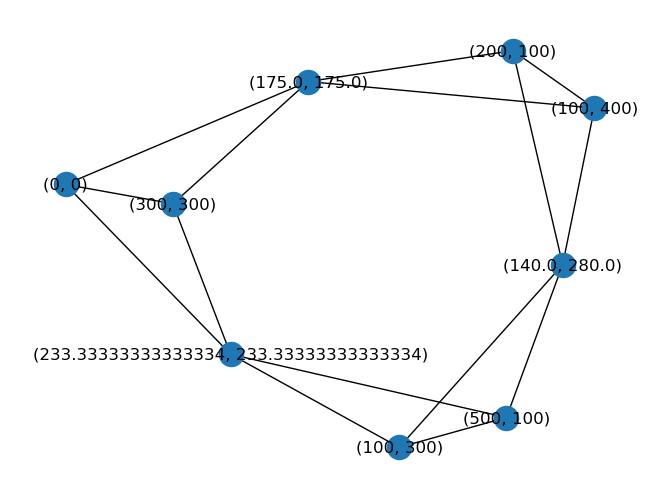

Detected Triangle with vertices [(500, 100), (233.33333333333334, 233.33333333333334), (100, 300)]
Detected Triangle with vertices [(0, 0), (300, 300), (233.33333333333334, 233.33333333333334)]
Detected Triangle with vertices [(0, 0), (175.0, 175.0), (300, 300)]
Detected Triangle with vertices [(200, 100), (100, 400), (175.0, 175.0)]
Detected Polygon with vertices [(140.0, 280.0), (100, 400), (175.0, 175.0), (300, 300), (233.33333333333334, 233.33333333333334), (100, 300)]
Detected Polygon with vertices [(140.0, 280.0), (200, 100), (175.0, 175.0), (300, 300), (233.33333333333334, 233.33333333333334), (100, 300)]
Detected Triangle with vertices [(500, 100), (140.0, 280.0), (100, 300)]


In [33]:
# Example usage
lines = [(0, 0, 300, 300), (200, 100, 100, 400), (100, 300, 500, 100)]
shapes = detect(lines)
for shape_type, vertices in shapes:
    print(f"Detected {shape_type} with vertices {vertices}")

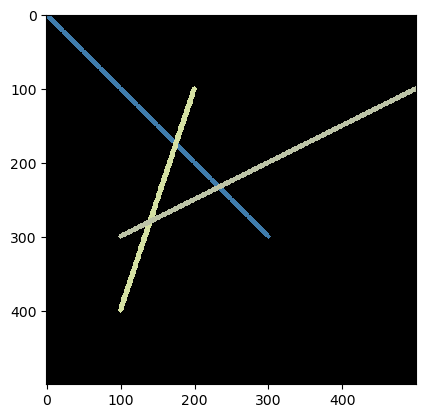

In [34]:
import cv2
import numpy as np
img = np.zeros((500, 500, 3), dtype=np.uint8)
cv2.line(img, (0, 0), (300, 300), (63, 124, 172), 5)
cv2.line(img, (200, 100), (100, 400), (213, 225, 163), 5)
cv2.line(img, (100, 300), (500, 100), (189, 196, 167), 5)
plt.imshow(img, interpolation='nearest')
plt.show()